# Notebook of ML with two ecosystem services 

## Libraries importations

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

## Data importation and cleaning

In [2]:
df = pd.read_csv(r'C:\Users\ACER\Documents\Projet IA\Datasets\ES_data.csv', sep = ";")
df.head()

,ws_id,awy,carbon,ed,shdi,forest_cover,anthropic_press,ndwi,lst,precip,area
0,18,77.606672,2870.000000,0.0,0.0,100.0,0.0,0.023966,29.982145,1079.009521,0.987370
1,61,94.580233,1167.111084,0.0,0.0,0.0,0.0,0.029602,29.934561,1049.414795,0.988460
2,64,110.492814,2687.333252,0.0,0.0,0.0,100.0,0.029312,29.890472,1069.757202,0.987440
3,106,113.392501,3000.000000,0.0,0.0,100.0,0.0,0.035724,29.794287,1038.476318,0.988459
4,33,118.140864,2666.666748,0.0,0.0,100.0,0.0,0.026479,29.966396,1073.403198,0.987617


In [3]:
df.describe()

,ws_id,awy,carbon,ed,shdi,forest_cover,anthropic_press,ndwi,lst,precip,area
count,120.000000,1.200000e+02,1.200000e+02,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,60.500000,3.508469e+05,4.651622e+06,31.769024,0.703384,50.998682,43.905624,0.029943,29.913000,1054.533562,2015.125161
std,34.785054,3.575675e+05,4.330297e+06,18.049599,0.389125,32.833964,33.285882,0.004458,0.094360,11.805257,1764.264050
min,1.000000,7.760667e+01,1.088889e+03,0.000000,0.000000,0.000000,0.000000,0.020801,29.746630,1031.634521,0.987370
25%,30.750000,5.881194e+04,7.625968e+05,23.649043,0.472383,20.122200,14.366802,0.026373,29.827815,1045.285858,344.712598
50%,60.500000,2.804920e+05,4.119904e+06,33.287581,0.787726,50.523524,41.566767,0.029617,29.924832,1053.352295,1782.669902
75%,90.250000,5.125215e+05,6.873458e+06,42.640758,0.986165,78.231962,76.705317,0.034014,29.984534,1062.420837,3076.516674
max,120.000000,1.900657e+06,2.229242e+07,68.429319,1.467926,100.000000,100.000000,0.037794,30.096491,1079.732666,8626.324109


## Add the normalized data of ES

In [4]:
df['awy_ha'] = df['awy']/df["area"] ## AWY normalized by area 
df['carbon_ha'] = df['carbon']/df['area'] ##Carbon normalized by area 

df = df.drop(['awy', 'carbon'], axis = 1)
df.head()

,ws_id,ed,shdi,forest_cover,anthropic_press,ndwi,lst,precip,area,awy_ha,carbon_ha
0,18,0.0,0.0,100.0,0.0,0.023966,29.982145,1079.009521,0.987370,78.599394,2906.712229
1,61,0.0,0.0,0.0,0.0,0.029602,29.934561,1049.414795,0.988460,95.684469,1180.737253
2,64,0.0,0.0,0.0,100.0,0.029312,29.890472,1069.757202,0.987440,111.898297,2721.516489
3,106,0.0,0.0,100.0,0.0,0.035724,29.794287,1038.476318,0.988459,114.716440,3035.027169
4,33,0.0,0.0,100.0,0.0,0.026479,29.966396,1073.403198,0.987617,119.622131,2700.101806


In [5]:
df.describe()

,ws_id,ed,shdi,forest_cover,anthropic_press,ndwi,lst,precip,area,awy_ha,carbon_ha
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,60.500000,31.769024,0.703384,50.998682,43.905624,0.029943,29.913000,1054.533562,2015.125161,168.454092,2305.940475
std,34.785054,18.049599,0.389125,32.833964,33.285882,0.004458,0.094360,11.805257,1764.264050,73.433268,429.690989
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.020801,29.746630,1031.634521,0.987370,78.599394,1101.856478
25%,30.750000,23.649043,0.472383,20.122200,14.366802,0.026373,29.827815,1045.285858,344.712598,138.282162,2132.808904
50%,60.500000,33.287581,0.787726,50.523524,41.566767,0.029617,29.924832,1053.352295,1782.669902,160.858266,2403.449944
75%,90.250000,42.640758,0.986165,78.231962,76.705317,0.034014,29.984534,1062.420837,3076.516674,173.133352,2613.160039
max,120.000000,68.429319,1.467926,100.000000,100.000000,0.037794,30.096491,1079.732666,8626.324109,643.436699,3036.926206


## Exploratory data analysis (correlation between variables)

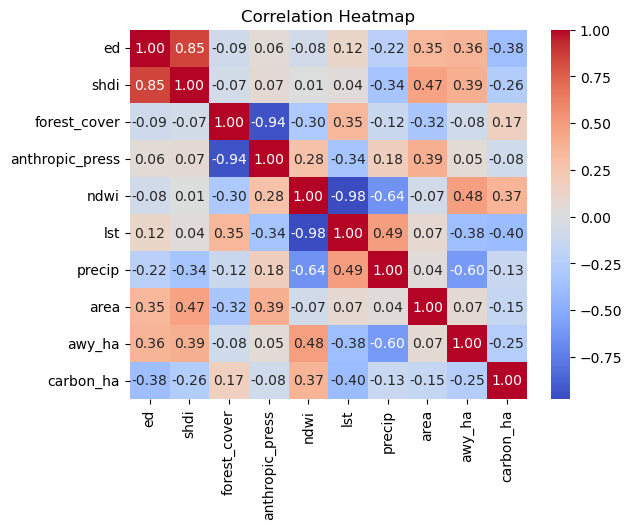

In [6]:
cor_matrix = df.iloc[:,1:].corr(method = 'spearman') ##Spearman correlation 

sns.heatmap(cor_matrix,  annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

## Modeling for carbon stock modeling

### Libraries importations 

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GroupKFold 
from sklearn.pipeline import Pipeline 
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor 
from sklearn.linear_model import LinearRegression, Ridge, Lasso 
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error

### Data split for carbon stock modeling

In [8]:
y_carb = df['carbon_ha']
y_water = df['awy_ha']
x = df.drop(['carbon_ha', 'awy_ha', "area"], axis = 1)

xcar_train, xcar_test, ycar_train, ycar_test = train_test_split(x, y_carb, train_size = 0.8, random_state = 42) 

In [9]:
groups = xcar_train["ws_id"] 
xcar_train_clean = xcar_train.drop("ws_id", axis = 1)
xcar_test_clean = xcar_test.drop("ws_id", axis = 1)

### Model implementations

In [10]:
models = {
    'LR' : LinearRegression(), 
    'Ridge' : Ridge(alpha = 1.0), 
    "Lasso" : Lasso(alpha = 1.0), 
    "AdaBoost" : AdaBoostRegressor(n_estimators = 100, learning_rate = 1.0, random_state = 24), 
    "RF" : RandomForestRegressor(random_state = 24),
    "XGB" : xgb.XGBRegressor(n_estimators = 100, learning_rate = 0.1, random_state = 24)
}

In [11]:
ycar_train.shape

(96,)

### Training and evaluation 

In [12]:
results = []
for name, model in models.items() : 
    pipe = Pipeline([
        ("Scaler", StandardScaler()), 
        ("Model", model)
    ])
    pipe.fit(xcar_train_clean, ycar_train) 
    
    spatial_folds = GroupKFold(n_splits = 5)

    cv = cross_val_score(pipe, xcar_train_clean, ycar_train, groups = groups, cv = spatial_folds, scoring = 'r2')

    y_pred = pipe.predict(xcar_test_clean)

    rmse = np.sqrt(mean_squared_error(ycar_test, y_pred)) 
    r2 = r2_score(ycar_test, y_pred)

    results.append({
        "Model":name, 
        "RMSE": rmse, 
        "R2" : r2
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by = "R2", ascending = False)
print("Models Performances for Carbon Storage")
print(results_df)

Models Performances for Carbon Storage
      Model        RMSE        R2
5       XGB  285.617320  0.471802
3  AdaBoost  306.901962  0.390144
4        RF  307.011262  0.389710
0        LR  325.540010  0.313822
2     Lasso  329.217741  0.298231
1     Ridge  331.722784  0.287510


### Graphics

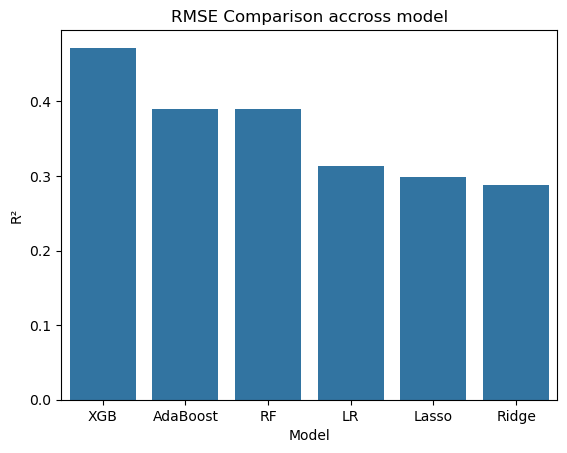

In [13]:
sns.barplot(x = "Model", y = "R2", data = results_df)
plt.title("RMSE Comparison accross model")
plt.xlabel("Model")
plt.ylabel("R²")
plt.show()

### Variables importances by SHAP 

In [14]:
import shap 

carbon_model = Pipeline([
    ('Scaler', StandardScaler()), 
    ('model', xgb.XGBRegressor(n_estimators = 100, learning_rate = 0.1, random_state = 24))
])

carbon_model.fit(xcar_train_clean, ycar_train)

,steps,"[('Scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None


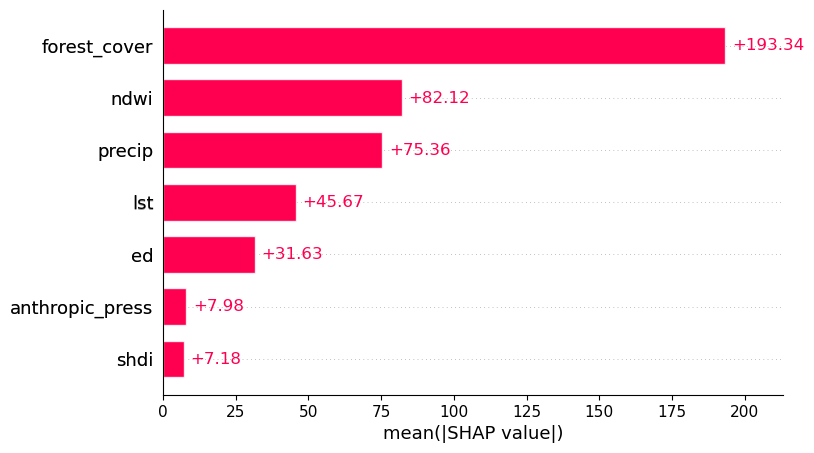

In [15]:
xgb_model = carbon_model.named_steps['model']

explainer = shap.Explainer(xgb_model)

shap_values = explainer(xcar_test_clean)

##Graphics 
shap.plots.bar(shap_values)
plt.show()

In [16]:
## Data Frame 
shap_data = pd.DataFrame(shap_values.values, columns = xcar_test_clean.columns)
shap_data = shap_data.mean()
print("SHAP Values for Carbon Storage")
print(shap_data)

SHAP Values for Carbon Storage
ed                 -15.753975
shdi                -6.421540
forest_cover       192.650925
anthropic_press     -7.978741
ndwi               -69.372993
lst                -45.669544
precip              75.357872
dtype: float32


## Modeling of Annual Runoff

### Data split for annual runoff

In [17]:
xwat_train, xwat_test, ywa_train, ywa_test = train_test_split(x, y_water, train_size = 0.8, random_state = 42) 

xwat_train_clean = xwat_train.drop('ws_id', axis = 1)
xwat_test_clean = xwat_test.drop('ws_id', axis  = 1)

### Training and evaluation

In [18]:
results_water = []
for name, model in models.items() : 
    pipe = Pipeline(
        [('Scaler', StandardScaler()), 
         ('Model', model)])

    pipe.fit(xwat_train_clean, ywa_train)

    cv = cross_val_score(pipe, xwat_train_clean, ywa_train, groups = groups, cv = spatial_folds, scoring = 'r2')

    y_pred = pipe.predict(xwat_test_clean) 
    rmse = np.sqrt(mean_squared_error(ywa_test, y_pred))
    r2 = r2_score(ywa_test, y_pred)

    results_water.append(
        {'Model' : name, 
            "RMSE" : rmse, 
            "R2": r2})

water_df = pd.DataFrame(results_water)
water_df = water_df.sort_values(by = "R2", ascending =  False)
print("Models Performances for Annual Runoff")
print(water_df)

Models Performances for Annual Runoff
      Model       RMSE        R2
5       XGB  19.171401  0.574854
3  AdaBoost  20.290509  0.523770
4        RF  26.540432  0.185208
2     Lasso  36.046615 -0.503003
1     Ridge  36.072306 -0.505146
0        LR  36.097980 -0.507289


### Graphics 

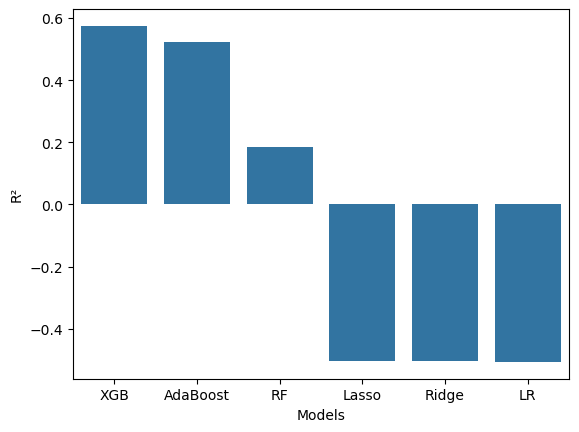

In [19]:
sns.barplot(x = "Model", y = "R2", data = water_df) 
plt.xlabel("Models")
plt.ylabel("R²") 
plt.show()

### Variables importances 

In [20]:
water_model = Pipeline(
    [('Scaler', StandardScaler()), 
    ('model', xgb.XGBRegressor(n_estimators = 100, learning_rate = 0.1, random_state = 24))])

water_model.fit(xwat_train_clean, ywa_train) 

,steps,"[('Scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None


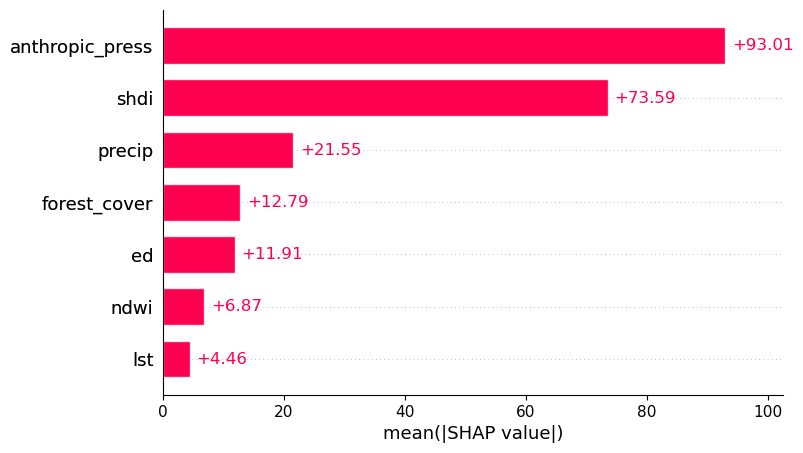

In [21]:
wa_model = water_model.named_steps['model']

wat_explainer = shap.Explainer(wa_model) 
wat_shap_values = wat_explainer(xwat_test_clean)

##Graphics 

shap.plots.bar(wat_shap_values)
plt.show()

In [22]:
water_shap = pd.DataFrame(wat_shap_values.values, columns = xwat_test_clean.columns)
water_shap = water_shap.mean()
print("SHAP Values for Annual Runoff")
print(water_shap)

SHAP Values for Annual Runoff
ed                -11.907361
shdi               68.381462
forest_cover      -12.462394
anthropic_press    90.457573
ndwi                6.865707
lst                -4.461806
precip            -21.550978
dtype: float32
